<a href="https://colab.research.google.com/github/amanpoonia/IV_closedform_BlackScholes/blob/main/IV_blackscholes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Option Implied Volatility by newton raphson method**


Root finding method used is Newton Raphson method

We want to find the root of the function =

C(black_scholes) - C(market)

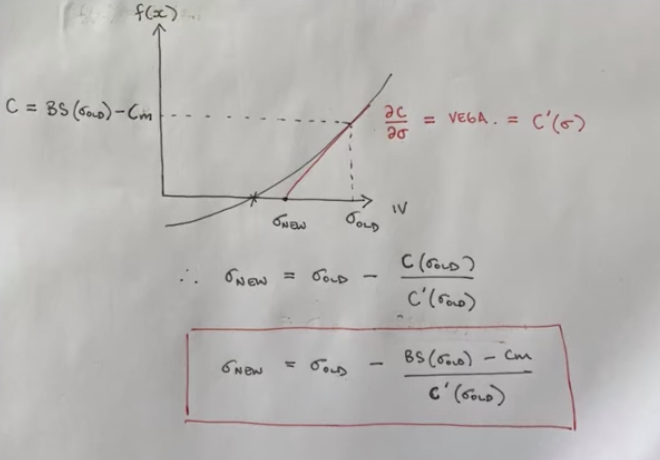

derivative of C function(difference between price of call obtained from Black Scholes and Observed call price in market) is VEGA


VEGA is sensitivity of the call price wrt Sigma

Our aim is to eventually converge to Zero

In [13]:
# Install py_vollib if it's not already installed
#!pip install py_vollib

""" Calculate implied volatility of an option using raphson newton method of root finding
"""

from py_vollib.black_scholes import black_scholes as bs
from py_vollib.black_scholes.greeks.analytical import vega

def implied_vol(S0, K, T, r, market_price_option, flag="c", tol = 0.00001):
  '''calculating implied volatility of an european option
    S0 : market price
    K : strike price
    T : time to maturity
    r : risk free interest rate
    market_price: market price of option
  '''
  max_iter = 200 #max no. of iterations #incase we dont converge to a solution #maybe the price with extremely far
  '''
  READ THE TEXT IN THE CELL BELOW
  '''
  vol_old = 0.3 #initial guess for newton raphspon

  for i in range(0, max_iter):

    bs_price = bs(flag, S0, K, T, r, vol_old)
    Cdash = vega(flag, S0, K, T, r, vol_old)*100
    diff = bs_price - market_price_option

    vol_new = vol_old - diff/Cdash
    new_bs_price = bs(flag, S0, K , r, T, vol_new)
    if (abs(vol_old - vol_new)< tol or abs(new_bs_price-market_price_option)<tol):
      break

    vol_old = vol_new
  implied_vol_new = vol_new
  return implied_vol_new


S0, K, r, T = 30, 28, 0.025, 0.5
market_price_option = 3
print(implied_vol(S0, K, T, r, market_price_option)*100)

19.10689849051207


The Market maker sets the IV.

they tend n ot to have negative IV or extremely high IV.

This is interesting. they make the market and hence they are the ones setting the IV.
READ MORE ABOUT IT?

What is the role of market maker and is the above commentary true?


**RESULTS**

28% for 3.7$ market price

if we go higher at 5$, IV increases to 45%
at 3$ - IV = 19%

if we go lower, no IV? at 2$
ANS: because we have fallen below the lower value of the function, as there is a lower bound to the theoritical black scholes price.

**QUESTIONS**

sticky strike vol and sticky delta vol?